# Pandas Practice Exercises

This notebook contains 40+ exercises to practice your Pandas skills. The exercises start from the basics and gradually increase in difficulty.

## Datasets Used
We will use a few common datasets available online. You can load them directly using the URLs provided in the exercises.
1. **Chipotle**: `https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv`
2. **Drinks**: `https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv`
3. **Titanic**: `https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`

---

## Section 1: Getting Started & Basic Data Structures


In [ ]:
# 1. Import pandas as pd and numpy as np
import pandas as pd
import numpy as np

In [ ]:
# 2. Print the version of pandas that has been imported.
print(pd.__version__)

2.2.2


In [ ]:
# 3. Create a pandas Series from the following list:
data = [10, 20, 30, 40, 50]
# Your code here
s=pd.Series(data)
print(s)

0    10
1    20
2    30
3    40
4    50
dtype: int64


In [ ]:
# 4. Create a DataFrame from the following dictionary:
data_dict = {
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'age': [25, 30, 35, 40],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston']
}
# Your code here
df=pd.DataFrame(data_dict)
print(df)

      name  age         city
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
3    David   40      Houston


In [ ]:
# 5. Set the 'name' column as the index of the DataFrame created in Q4.
df = df.set_index('name')

---
## Section 2: Loading Data & Basic Exploration
For this section, we will use the **Chipotle** dataset.
URL: `https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv`
*Note: This file is tab-separated.*


In [ ]:
# 6. Load the dataset into a variable called `chipo`.
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'
# Your code here
chipo = pd.read_csv(url, sep='\t')

In [ ]:
# 7. Show the first 10 entries of the dataframe.
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


In [ ]:
# 8. What is the number of observations (rows) and columns in the dataset?
chipo.shape
#4622 rows are there and 5 columns

(4622, 5)

In [ ]:
# 9. Print the name of all the columns.
chipo.columns

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='object')

In [ ]:
# 10. How is the dataset indexed?
chipo.index


RangeIndex(start=0, stop=4622, step=1)

---
## Section 3: Data Cleaning & Manipulation
Continue using the `chipo` dataframe.


In [ ]:
# 11. Check the data type of each column.
chipo.dtypes

,0
order_id,int64
quantity,int64
item_name,object
choice_description,object
item_price,object


In [ ]:
# 12. The 'item_price' column is currently an object (string) because of the '$' sign.
# Clean this column: remove the '$' and convert it to a float.
chipo['item_price'] = chipo['item_price'].str.replace('$', '', regex=False)
chipo['item_price'] = chipo['item_price'].astype(float)


In [ ]:
# 13. Are there any missing values in the dataset? Check for nulls.
chipo.isnull().sum()


,0
order_id,0
quantity,0
item_name,0
choice_description,1246
item_price,0


In [ ]:
# 14. Drop any duplicate rows, if they exist.
print(chipo.duplicated().sum())
chipo = chipo.drop_duplicates()
print(chipo.duplicated().sum())

59
0


In [ ]:
# 15. Create a new column 'revenue' which is the product of 'quantity' and 'item_price'.
chipo['revenue'] = chipo['quantity'] * chipo['item_price']

---
## Section 4: Filtering & Sorting


In [ ]:
# 16. Sort the dataframe by 'item_price' in descending order.
chipo.sort_values(by='item_price', ascending=False, inplace=True)


In [ ]:
# 17. How many items cost more than $10.00?
(chipo['item_price'] > 10).sum()

np.int64(1123)

In [ ]:
# 18. What is the price of each item?
# (Hint: print a dataframe with only two columns: item_name and item_price, drop duplicates)
item_prices = chipo[['item_name', 'item_price']].drop_duplicates()
item_prices

,item_name,item_price
3598,Chips and Fresh Tomato Salsa,44.25
3480,Carnitas Bowl,35.25
3602,Chicken Burrito,35.00
3601,Veggie Burrito,33.75
409,Chicken Bowl,32.94
...,...,...
32,Side of Chips,1.69
3092,Bottled Water,1.50
4552,Canned Soft Drink,1.25
28,Canned Soda,1.09


In [ ]:
# 19. Select only the items where the name is 'Chicken Bowl'.
chicken_bowl = chipo[chipo['item_name'] == 'Chicken Bowl']
chicken_bowl

,order_id,quantity,item_name,choice_description,item_price,revenue
409,178,3,Chicken Bowl,"[[Fresh Tomato Salsa (Mild), Tomatillo-Green C...",32.94,98.82
1514,616,3,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",26.25,78.75
4423,1764,2,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Fajita Vegetables,...",22.50,45.00
2510,997,2,Chicken Bowl,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",22.50,45.00
1429,578,2,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Sour Cream, Guacam...",22.50,45.00
...,...,...,...,...,...,...
3265,1307,1,Chicken Bowl,"[Roasted Chili Corn Salsa (Medium), [Black Bea...",8.49,8.49
1651,667,1,Chicken Bowl,"[Roasted Chili Corn Salsa (Medium), [Rice, Che...",8.49,8.49
2918,1160,1,Chicken Bowl,"[Fresh Tomato (Mild), [Rice, Sour Cream, Cheese]]",8.19,8.19
3664,1466,1,Chicken Bowl,"[Fresh Tomato (Mild), [Lettuce, Fajita Veggies...",8.19,8.19


In [ ]:
# 20. Select items where the name is 'Chicken Bowl' AND the quantity is greater than 1.
chipo[(chipo['item_name'] == 'Chicken Bowl') & (chipo['quantity'] > 1)]


,order_id,quantity,item_name,choice_description,item_price,revenue
409,178,3,Chicken Bowl,"[[Fresh Tomato Salsa (Mild), Tomatillo-Green C...",32.94,98.82
1514,616,3,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",26.25,78.75
4423,1764,2,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Fajita Vegetables,...",22.50,45.00
2510,997,2,Chicken Bowl,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",22.50,45.00
1429,578,2,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Sour Cream, Guacam...",22.50,45.00
3508,1410,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Pinto Beans...",21.96,43.92
2525,1004,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Rice, Fajit...",21.96,43.92
2075,837,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Pinto Beans...",21.96,43.92
2942,1170,2,Chicken Bowl,"[Tomatillo-Green Chili Salsa (Medium), [Black ...",21.96,43.92
3843,1540,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Rice, Pinto...",21.96,43.92


---
## Section 5: Aggregation & Grouping
For this section, we will use the **Drinks** dataset.
URL: `https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv`


In [ ]:
# 21. Load the drinks dataset into a variable called `drinks`.
url_drinks = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv'
# Your code here
drinks=pd.read_csv(url_drinks)

In [ ]:
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


In [ ]:
# 22. Which continent drinks more beer on average?
grouped = drinks.groupby('continent')
avg_beer = grouped['beer_servings'].mean()
avg_beer.sort_values(ascending=False)
#EU drinks the most on average

,beer_servings
continent,
EU,193.777778
SA,175.083333
OC,89.687500
AF,61.471698
AS,37.045455


In [ ]:
# 23. For each continent, print the statistics for wine consumption.
grouped = drinks.groupby('continent')
wine = grouped['wine_servings']
wine.describe()

,count,mean,std,min,25%,50%,75%,max
continent,,,,,,,,
AF,53.0,16.264151,38.846419,0.0,1.0,2.0,13.00,233.0
AS,44.0,9.068182,21.667034,0.0,0.0,1.0,8.00,123.0
EU,45.0,142.222222,97.421738,0.0,59.0,128.0,195.00,370.0
OC,16.0,35.625000,64.555790,0.0,1.0,8.5,23.25,212.0
SA,12.0,62.416667,88.620189,1.0,3.0,12.0,98.50,221.0


In [ ]:
# 24. Print the mean alcohol consumption per continent for every column.
grouped = drinks.groupby('continent')
numeric_data = drinks.select_dtypes(include='number')
mean_consumption = numeric_data.groupby(drinks['continent']).mean()
mean_consumption


,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
continent,,,,
AF,61.471698,16.339623,16.264151,3.007547
AS,37.045455,60.840909,9.068182,2.170455
EU,193.777778,132.555556,142.222222,8.617778
OC,89.687500,58.437500,35.625000,3.381250
SA,175.083333,114.750000,62.416667,6.308333


In [ ]:
# 25. Print the median alcohol consumption per continent for every column.
grouped = drinks.groupby('continent')
numeric_data = drinks.select_dtypes(include='number')
median_consumption = numeric_data.groupby(drinks['continent']).median()
median_consumption

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
continent,,,,
AF,32.0,3.0,2.0,2.30
AS,17.5,16.0,1.0,1.20
EU,219.0,122.0,128.0,10.00
OC,52.5,37.0,8.5,1.75
SA,162.5,108.5,12.0,6.85


---
## Section 6: Apply & Advanced Selection
Back to the `chipo` dataset


In [ ]:
# 26. Create a function that returns "High" if a price is > 10 and "Low" otherwise.
# Apply this function to the 'item_price' column of `chipo` and create a new column 'price_level'.
def price_level(price):
    if price > 10:
        return "High"
    else:
        return "Low"

chipo['price_level'] = chipo['item_price'].apply(price_level)

In [ ]:
# 27. Use the `apply` method to capitalize all strings in the 'item_name' column.
chipo['item_name'] = chipo['item_name'].apply(lambda x: x.capitalize())

In [ ]:
# 28. Select only the rows from index 10 to 20 (inclusive) and columns 1 to 3.
chipo_= chipo.iloc[10:21, 1:4]
chipo_


,quantity,item_name,choice_description
3636,3,Chicken burrito,"[Fresh Tomato Salsa, Rice]"
3334,3,Steak bowl,"[Tomatillo Green Chili (Medium), [Rice, Black ..."
613,2,Steak salad bowl,"[Tomatillo Red Chili Salsa, [Fajita Vegetables..."
281,2,Steak salad bowl,"[Tomatillo Red Chili Salsa, [Black Beans, Chee..."
1566,2,Steak bowl,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees..."
3754,2,Steak bowl,"[Tomatillo Red Chili Salsa, [Fajita Vegetables..."
4427,2,Steak bowl,"[Fresh Tomato Salsa, [Rice, Pinto Beans, Sour ..."
1753,2,Steak burrito,"[Tomatillo Green Chili Salsa, [Fajita Vegetabl..."
506,2,Carnitas bowl,"[Roasted Chili Corn Salsa, [Fajita Vegetables,..."
4307,2,Steak bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Sour ..."


---
## Section 7: Merging & Joining


In [ ]:
# 29. Create two dataframes:
df1 = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['Alice', 'Bob', 'Charlie']})
df2 = pd.DataFrame({'ID': [2, 3, 4], 'Score': [85, 90, 95]})

# Merge them on 'ID' using an inner join.
merged_df = pd.merge(df1, df2, on='ID', how='inner')
merged_df


,ID,Name,Score
0,2,Bob,85
1,3,Charlie,90


In [ ]:
# 30. Merge them on 'ID' using an outer join.
merged_df = pd.merge(df1, df2, on='ID', how='outer')
merged_df


,ID,Name,Score
0,1,Alice,NaN
1,2,Bob,85.0
2,3,Charlie,90.0
3,4,NaN,95.0


In [ ]:
# 31. Merge them on 'ID' using a left join (keep all from df1).
merged_left = pd.merge(df1, df2, on='ID', how='left')
merged_left


,ID,Name,Score
0,1,Alice,NaN
1,2,Bob,85.0
2,3,Charlie,90.0


---
## Section 8: Time Series
For this section, let's generate some time series data.


In [ ]:
# 32. Create a date range from '2023-01-01' to '2023-01-10'.
dates = pd.date_range(start='2023-01-01', end='2023-01-10')
dates

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
# 33. Create a DataFrame with this date range as the index and a column 'Sales' with random values.
dates = pd.date_range(start='2023-01-01', end='2023-01-10')
df_sales = pd.DataFrame({
    'Sales': np.random.randint(100, 500, size=len(dates))   # random numbers
}, index=dates)

df_sales

,Sales
2023-01-01,394
2023-01-02,487
2023-01-03,368
2023-01-04,207
2023-01-05,104
2023-01-06,191
2023-01-07,313
2023-01-08,486
2023-01-09,286
2023-01-10,191


In [ ]:
# 34. Resample the data to calculate the 3-day sum of sales.
three_day_sum = df_sales.resample('3D').sum()
three_day_sum

,Sales
2023-01-01,1249
2023-01-04,502
2023-01-07,1085
2023-01-10,191


In [ ]:
# 35. Shift the 'Sales' column by 1 day (create a lag column).
df_sales['Sales_lag1'] = df_sales['Sales'].shift(1)
df_sales

,Sales,Sales_lag1
2023-01-01,394,NaN
2023-01-02,487,394.0
2023-01-03,368,487.0
2023-01-04,207,368.0
2023-01-05,104,207.0
2023-01-06,191,104.0
2023-01-07,313,191.0
2023-01-08,486,313.0
2023-01-09,286,486.0
2023-01-10,191,286.0


---
## Section 9: Titanic Dataset - Mixed Practice
URL: `https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`


In [ ]:
# 36. Load the Titanic dataset.
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# Your code here
titanic = pd.read_csv(url_titanic)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 37. How many passengers survived? (Survived=1)
titanic['Survived'].sum()

np.int64(342)

In [ ]:
# 38. What is the average age of passengers?
titanic['Age'].mean()

np.float64(29.69911764705882)

In [ ]:
# 39. Group by 'Pclass' and calculate the survival rate (mean of 'Survived').
survival_rate_by_class = titanic.groupby('Pclass')['Survived'].mean()
survival_rate_by_class

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
# 40. Fill missing values in the 'Age' column with the median age.
median_age = titanic['Age'].median()
titanic['Age'] = titanic['Age'].fillna(median_age)

In [ ]:
# 41. Create a pivot table showing the average age by 'Sex' and 'Pclass'.
pivot_age = titanic.pivot_table(values='Age', index='Sex', columns='Pclass', aggfunc='mean')
pivot_age

Pclass,1,2,3
Sex,,,
female,33.978723,28.703947,23.572917
male,38.995246,30.512315,26.911873


---
## Section 10: Visualization (Optional)
Requires matplotlib/seaborn


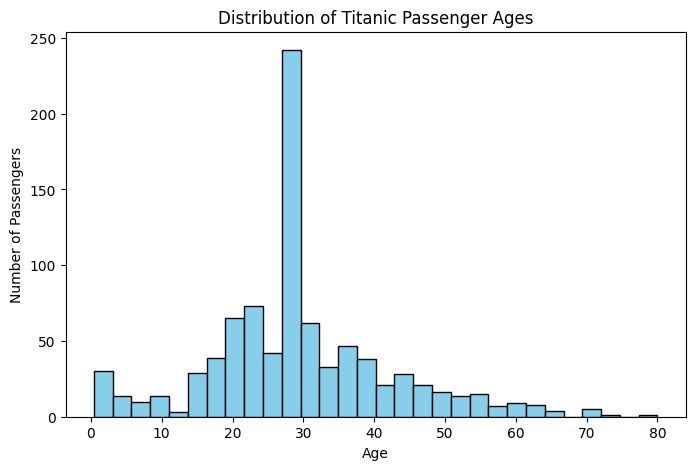

In [ ]:
# 42. Plot a histogram of the 'Age' column from the Titanic dataset.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(titanic['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Titanic Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

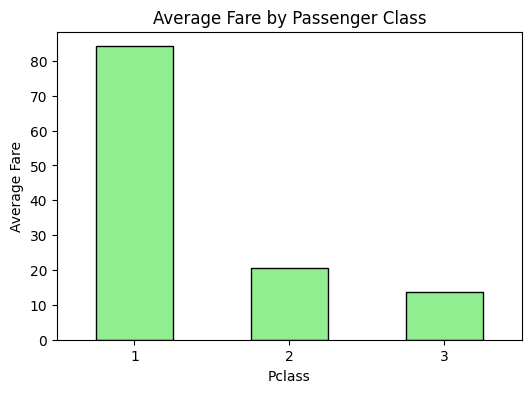

In [ ]:
# 43. Plot a bar chart of the average fare by Pclass.
import matplotlib.pyplot as plt

avg_fare = titanic.groupby('Pclass')['Fare'].mean()

plt.figure(figsize=(6,4))
avg_fare.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average Fare by Passenger Class')
plt.xlabel('Pclass')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.show()


---
## Great Job!
You've covered the basics of Pandas including creating objects, reading data, cleaning, filtering, grouping, merging, and time series.
